In [1]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.dates as mdates

In [2]:
timeline = [
    (1590, "Janssen builds compound microscope"),
    (1609, "Galileo builds compound microscope"),
    (1625, "Faber coins term 'microscope'"),
    (1665, "Hooke publishes Micrographia, first use of 'cell'"),
    (1674, "Leeuwenhoek observes bacteria and living cells"),
    (1835, "Airy describes diffraction (Airy disk)"),
    (1840, "Photomicrophraphs used to capture microscopy images"),
    (1852, "Term 'fluorescence' introduced"),
    (1871, "First fluorescent dye (fluorescein) invented"),
    (1873, "Abbe formulates diffraction limit"),
    (1880, "Film-based camera systems are introduced to microscopy systems"),
    (1950, "Phase contrast & DIC microscopy developed"),
    (1957, "Minsky patents confocal microscopy"),
    (1961, "GFP isolated from Aequorea victoria"),
    (1962, "TV-based image analyzer developed"),
    (1969, "First digital camera system introduced to a microscope system"),
    (1980, "TIRF microscopy developed"),
    (1986, "First digital microscope manufactured"),
    (1987, "NIH Image is developed and circulated on floppy disk"),
    (1990, "Super-resolution microscopy concepts (STED, PALM, STORM) emerge"),
    (1992, "GFP cloned and sequenced"),
    (1993, "OPFOS optical sectioning introduced (Light-sheet microscopy)"),
    (1994, "GFP used in C. elegans"),
    (2001, "NIH Image becomes ImageJ"),
    (2004, "SPIM introduced for 3D live imaging"),
    (2015, "Expansion microscopy developed"),
    (2018, "Two-photon structured illumination (TP-SIM)"),
    (2019, "Multiphoton superresolution (MP-SPIFI)"),
    (2021, "3D-STED super-resolution imaging in living mouse brain"),
    (2022, "Three-photon adaptive optics microscopy (deep brain imaging)"),
    (2024, "20× Expansion Microscopy (20ExM) <20 nm resolution")
]


C:\Users\Kristin.Gallik\AppData\Local\Temp\ipykernel_7636\176305483.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


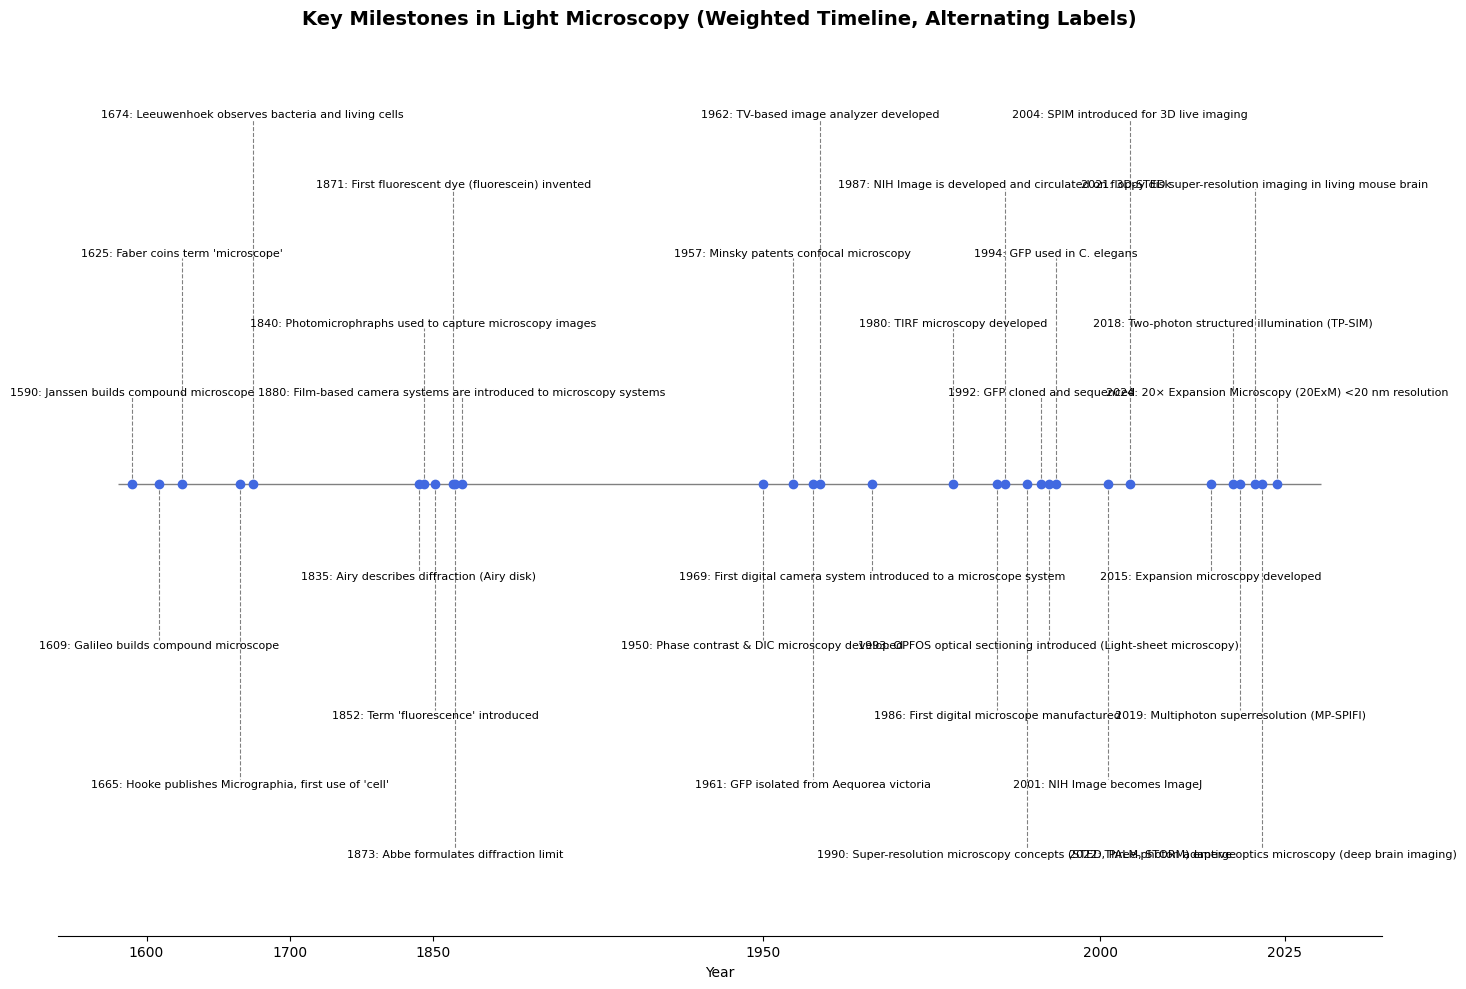

In [40]:
years, events = zip(*timeline)

# ---- Weighted spacing ----
original_breaks = [1580, 1700, 1880, 1960, 2030]
weighted_positions = [0, 1, 2, 4, 7]  # nonlinear spacing
mapped_years = np.interp(years, original_breaks, weighted_positions)

# Plot setup
fig, ax = plt.subplots(figsize=(15, 10),layout="constrained")
ax.hlines(0, min(weighted_positions), max(weighted_positions), color="gray", linewidth=1)

# Initialize label positions alternating above and below
label_y = np.zeros(len(mapped_years))
for i in range(len(label_y)):
    direction = 1 if i % 2 == 0 else -1  # alternate top/bottom
    label_y[i] = direction * (0.5 + (i % 5) * 0.4)  # staggered levels

# Collision-avoidance adjustment
min_gap = 0.5
for i in range(1, len(label_y)):
    # Only check if labels are on the same side (same direction)
    if np.sign(label_y[i]) == np.sign(label_y[i-1]):
        if abs(label_y[i] - label_y[i-1]) < min_gap and abs(mapped_years[i] - mapped_years[i-1]) < 0.2:
            label_y[i] = label_y[i-1] + np.sign(label_y[i]) * min_gap

# Plot events
ax.scatter(mapped_years, [0]*len(mapped_years), color="royalblue", zorder=3)

# Add labels with connector lines
for x, y, year, event in zip(mapped_years, label_y, years, events):
    va = "bottom" if y > 0 else "top"
    ax.text(x, y, f"{year}: {event}",
            ha="center", va=va, fontsize=8, rotation=0)
    ax.plot([x, x], [0, y], color="gray", linewidth=0.8, linestyle="--", zorder=2)

# Axis formatting
tick_years = [1600, 1700, 1850, 1950, 2000, 2025]
tick_pos = np.interp(tick_years, original_breaks, weighted_positions)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_years)

ax.set_ylim(-max(label_y) - 0.5, max(label_y) + 0.5)
ax.set_yticks([])
ax.set_xlabel("Year", fontsize=10)
ax.set_title("Key Milestones in Light Microscopy (Weighted Timeline, Alternating Labels)", 
             fontsize=14, weight="bold")
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

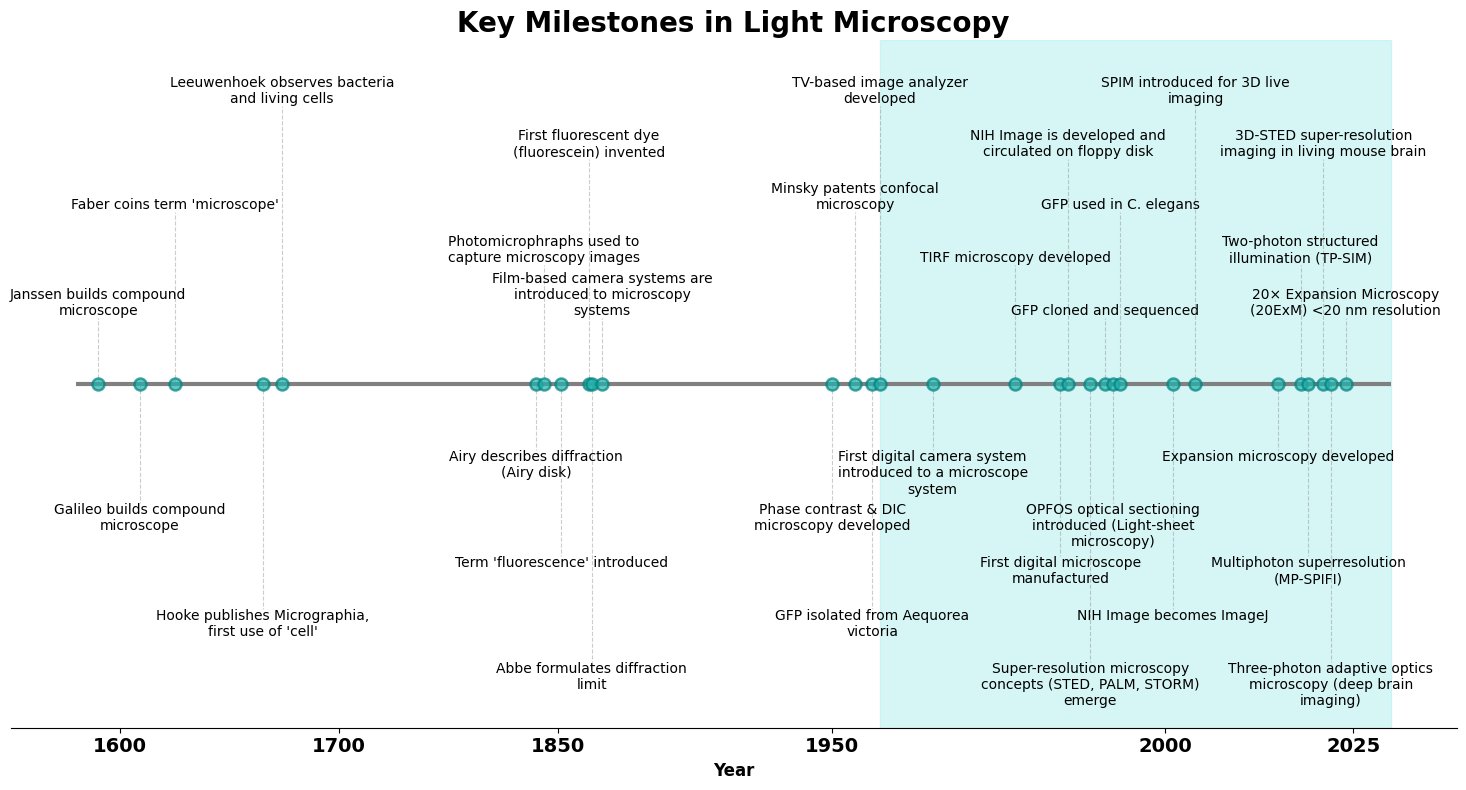

In [9]:
import textwrap

years, events = zip(*timeline)

# ---- Weighted spacing ----
original_breaks = [1580, 1700, 1880, 1960, 2030]
weighted_positions = [0, 1, 2, 3, 5]  # nonlinear spacing
mapped_years = np.interp(years, original_breaks, weighted_positions)

# Plot setup
fig, ax = plt.subplots(figsize=(15, 8))
ax.hlines(0, min(weighted_positions), max(weighted_positions), color="gray", linewidth=3)

# Add a highlighted region from 1968 to the end
highlight_years = [1962, 2030]  # Define the year range to highlight
highlight_pos = np.interp(highlight_years, original_breaks, weighted_positions)
ax.axvspan(highlight_pos[0], max(weighted_positions), color='paleturquoise', alpha=0.5, zorder=1)

# Initial label positions with alternating top/bottom
label_y = np.zeros(len(mapped_years))
for i in range(len(label_y)):
    # Alternate top (positive) and bottom (negative) with stagger levels
    level = 0.5 + (i % 5) * 0.4
    label_y[i] = level if i % 2 == 0 else -level

# Collision-avoidance adjustment
min_gap = 0.3
for i in range(1, len(label_y)):
    if abs(label_y[i] - label_y[i-1]) < min_gap and abs(mapped_years[i] - mapped_years[i-1]) < 0.2:
        if label_y[i] > 0:
            label_y[i] = label_y[i-1] + min_gap
        else:
            label_y[i] = label_y[i-1] - min_gap

# Plot events
ax.scatter(mapped_years, [0]*len(mapped_years), color="lightseagreen", zorder=3,s=75,alpha=0.7,edgecolor="teal",linewidth=1.75)

# Add labels with connector lines and wrap text
for x, y, year, event in zip(mapped_years, label_y, years, events):
    wrapped_event = "\n".join(textwrap.wrap(f"{event}", width=30))
    va = "bottom" if y > 0 else "top"
    ax.text(x, y, wrapped_event, ha="center", va=va, fontsize=10, rotation=0)
    ax.plot([x, x], [0, y], color="gray", linewidth=0.8, linestyle="--", zorder=2, alpha=0.4)

# Axis formatting
tick_years = [1600, 1700, 1850, 1950, 2000, 2025]
tick_pos = np.interp(tick_years, original_breaks, weighted_positions)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_years, fontsize=14,weight='bold')

ax.set_ylim(min(label_y) - 0.5, max(label_y) + 0.5)
ax.set_yticks([])
ax.set_xlabel("Year", fontsize=12, weight='bold')
ax.set_title("Key Milestones in Light Microscopy", 
             fontsize=20, weight="bold")
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
fig.savefig(r'C:\Users\kristin.gallik\OneDrive - Van Andel Institute\Workshops_Seminars\Presentations\Designing_Quant_Microscopy_Exp\timeline.png',dpi=300)